In [1]:
import sys
sys.path.append('/home/semik/projekty/noncanonical_introns/')

import pathlib
pathlib.Path().absolute()

import introns
from tabulate import tabulate

In [2]:
path="/mnt/archive/euglena_genomy/"
path_rev="./fastas_and_gff/reversed_fasta_gtf/"

genom_EG=path+"gracilis/gracilis_dbg2olc.fasta"
geny_EG=path+"gracilis/gracilis_stringtie_strand_informed.gtf"
geny_EG_rev=path_rev+"gracilis_stringtie_strand_informed_reversed.gtf"

genom_EH=path+'hiemalis/hiemalis_rascaf.fasta'
geny_EH=path+'hiemalis/stringtie_strand_informed3.gtf'
geny_EH_rev=path_rev+"stringtie_strand_informed3_reversed.gtf"

genom_EL=path+'longa/longa_rascaf.fasta'
geny_EL=path+'longa/longa_stringtie_strand_informed.gtf'
geny_EL_rev=path_rev+"longa_stringtie_strand_informed_reversed.gtf"

#genom_bugtest = '/home/semik/projekty/noncanonical_introns/bugtest.fasta'
#geny_bugtest = '/home/semik/projekty/noncanonical_introns/bugtest.gtf'
#geny_bugtest_rev = '/home/semik/projekty/noncanonical_introns/bugtest_reversed.gtf'
genom_bugtest = './fastas_and_gff/bugtest.fasta'
geny_bugtest = './fastas_and_gff/bugtest.gtf'
geny_bugtest_rev = './fastas_and_gff/bugtest_reversed.gtf'

In [3]:
#genome_bugtest, genes_bugtest, genes_bugtest_rev = introns.HELP_load_default_genome_genes("bugtest", True)

In [4]:
genome_EG, genes_EG, genes_EG_rev = introns.HELP_load_default_genome_genes("EG", True)

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 275238/275238 [04:57<00:00, 925.48it/s] 


[CREATE] Genes, sequences, introns, exons created, introns' classes predicted
Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 275238/275238 [04:56<00:00, 929.68it/s] 

[CREATE] Genes, sequences, introns, exons created, introns' classes predicted


In [5]:
genome_EH, genes_EH, genes_EH_rev = introns.HELP_load_default_genome_genes("EH", True)

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 95472/95472 [03:17<00:00, 483.01it/s]


[CREATE] Genes, sequences, introns, exons created, introns' classes predicted
Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 95472/95472 [02:53<00:00, 549.89it/s]

[CREATE] Genes, sequences, introns, exons created, introns' classes predicted


In [6]:
genome_EL, genes_EL, genes_EL_rev = introns.HELP_load_default_genome_genes("EL", True)

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 38192/38192 [01:24<00:00, 452.53it/s]


[CREATE] Genes, sequences, introns, exons created, introns' classes predicted
Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 38192/38192 [00:52<00:00, 731.93it/s]

[CREATE] Genes, sequences, introns, exons created, introns' classes predicted


In [7]:
def create_both(genome,genes,genes_rev):
    genome_eug, genes_eug = introns.create_genes(genome,genes)
    genome_eug,genes_eug_rev = introns.create_genes(genome,genes_rev)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
    return genome_eug,genes_eug, genes_eug_rev
    
def stats(genome_eug,genes_eug):  
    conv_count=0
    nconv_count=0
    both_count=0
    all_count=0
    non_count=0
    conventional_classes=[0,0,0,0,0,0,0,0]
    nonconventional_classes=[0,0,0,0,0,0,0,0,0]

    for name, gene in list(genes_eug.items()):
        for intron in gene.introns:
            all_count+=1

            if intron.best_nonconv_var and not intron.best_conv_var:
                nonconventional_classes[intron.best_nonconv_var-1]+=1
                nconv_count+=1
            elif intron.best_conv_var and not intron.best_nonconv_var:
                conventional_classes[intron.best_conv_var-1]+=1
                conv_count+=1
            elif intron.best_conv_var and intron.best_nonconv_var:
                both_count+=1
            else:
                non_count+=1
    print("""
          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}""")
    return conventional_classes, nonconventional_classes, conv_count,nconv_count, both_count,non_count,all_count

In [8]:
#genome_bugtest, genes_bugtest, genes_bugtest_rev = introns.create_both(genom_bugtest, geny_bugtest,
#                                                               geny_bugtest_rev, 'stringtie')
#genome_EG, genes_EG, genes_EG_rev = introns.create_both(genom_EG, geny_EG, geny_EG_rev, 'stringtie')
#genome_EH, genes_EH, genes_EH_rev = introns.create_both(genom_EH, geny_EH, geny_EH_rev, 'stringtie')
#genome_EL, genes_EL, genes_EL_rev = introns.create_both(genom_EL, geny_EL, geny_EL_rev, 'stringtie')

In [9]:
def liczenie_ocen_genow(genes, genes_rev, conv_classes, nonconv_classes):
    ulamki_niekonw=[i/all_count for i in nonconv_classes]
    punktacja_niekonw = [1/sqrt(sum(ulamki_niekonw[:a+1])) for a in range(len(nonconv_classes))]
    
    kolejnosc=[j[0] for j in sorted(wagi.items(), key=lambda i: i[1])][1:]
    conv_classes=[conv_classes[k-1] for k in kolejnosc]
    ulamki_konw = [i/all_count for i in conv_classes]
    punktacja_konw = [1/sqrt(sum(ulamki_konw[:a+1])) for a in range(len(conv_classes))]
    #punktacja_konw = [1/sum(ulamki_konw[:a+1]) for a in range(len(conv_classes))]
    #punktacja_konw = [1/sum([sqrt(u) for u in ulamki_konw][:a+1]) for a in range(len(conv_classes))]
    zlegeny,wszystkiegeny=[],[]
    geny1, geny2= list(genes.items()), list(genes_rev.items())
    
    for i in range(len(geny1)):
        punkty_basic,punkty_rev = 0, 0
        ilosc_intronow_genu=len(geny1[i][1].introns)
        for j in range(ilosc_intronow_genu):
            
            int1,int2=geny1[i][1].introns[j], geny2[i][1].introns[j]
            oceny1, oceny2 = [], []
            if int1.best_conv_var: oceny1.append(punktacja_konw[int1.best_conv_var-1])
            if int2.best_conv_var: oceny2.append(punktacja_konw[int1.best_conv_var-1])
            if int1.best_nonconv_var: oceny1.append(punktacja_niekonw[int1.best_nonconv_var-1])
            if int2.best_nonconv_var: oceny2.append(punktacja_niekonw[int2.best_nonconv_var-1])
            
            punkty_basic = max(oceny1) if oceny1 else 0
            punkty_rev= max(oceny2) if oceny2 else 0
                
        if ilosc_intronow_genu: ocena=(punkty_basic-punkty_rev)/ilosc_intronow_genu
        else: ocena=0
        if ocena<0:
            zlegeny.append((geny1[i][0], ocena))
        wszystkiegeny.append((geny1[i][1],geny2[i][1], ocena))
    return zlegeny,wszystkiegeny

In [10]:
print('gracilis')
liczenie_intronow_dla_dwoch(genes_EG, genes_EG_rev)
print('\nhiemalis')
liczenie_intronow_dla_dwoch(genes_EH, genes_EH_rev)
print('\nlonga')
liczenie_intronow_dla_dwoch(genes_EL, genes_EL_rev)
#print('\nbugtest')
#liczenie_intronow_dla_dwoch(genes_bugtest, genes_bugtest_rev)


gracilis
dlugosci True
                  konwencjonalne    niekonwencjonalne
--------------  ----------------  -------------------
dobry kierunek             92352                70161
reversed                   93789                69701
Czy jest wiecej konwencjonalnych w dobrym kierunku: False , czy jest wiecej niekonwencjonalnych: True

hiemalis
dlugosci True
                  konwencjonalne    niekonwencjonalne
--------------  ----------------  -------------------
dobry kierunek             88728                86546
reversed                   21130                23257
Czy jest wiecej konwencjonalnych w dobrym kierunku: True , czy jest wiecej niekonwencjonalnych: True

longa
dlugosci True


IndexError: list index out of range

In [11]:
Ms=[]
#for name,genome,genes,genes_rev in [("bugtest reversed", genom,geny,geny_rev)]:
for name,genome,genes,genes_rev in [#("bugtest reversed", genome_bugtest, genes_bugtest, genes_bugtest_rev),
                                    ("gracilis reversed",genome_EG, genes_EG, genes_EG_rev),
                                    ("hiemalis reversed", genome_EH, genes_EH, genes_EH_rev),
                                    ("longa reversed",genome_EL, genes_EL, genes_EL_rev)]:
    #genome_eug, genes_eug=create(genome,genes)
    conventional_classes, nonconventional_classes, conv_count,nconv_count, both_count,non_count,all_count = stats(genome, genes)
    #genome_eug, genes_eug_rev=create(genome,genes_rev)
    conventional_classes_rev, nonconventional_classes_rev, conv_count_rev,nconv_count_rev, both_count_rev,non_count_rev,all_count_rev = stats(genome, genes_rev)
    M=[name, ["typ","konwencjonalne","niekonwencjonalne","oba","inne","wszystkie"],["dobre",conv_count,nconv_count, both_count,non_count,all_count],["reversed",conv_count_rev,nconv_count_rev, both_count_rev,non_count_rev,all_count_rev]]
    Ms.append(M)


          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}

          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}

          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}

          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}

          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}

          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}


In [12]:
for M in Ms:
    print("\n", M[0])
    print(tabulate(M[2:], headers=M[1]))


 gracilis reversed
typ         konwencjonalne    niekonwencjonalne    oba    inne    wszystkie
--------  ----------------  -------------------  -----  ------  -----------
dobre                92352                70161   3555  856729      1015687
reversed             93789                69701   3754  855951      1015687

 hiemalis
typ         konwencjonalne    niekonwencjonalne    oba    inne    wszystkie
--------  ----------------  -------------------  -----  ------  -----------
dobre                88728                86546   3289  502005       673990
reversed             21130                23257   2930  632533       673990

 longa
typ         konwencjonalne    niekonwencjonalne    oba    inne    wszystkie
--------  ----------------  -------------------  -----  ------  -----------
dobre                22775                15953    780  183323       221271
reversed             20583                12059    772  189401       221271


In [13]:
genome_bugtest, genes_bugtest, genes_bugtest_rev = create_both(genom_bugtest, geny_bugtest, geny_bugtest_rev)
genome_EG, genes_EG, create= create_both(genom_EG, geny_EG, geny_EG_rev)
genome_EH, genes_EH, genes_EH_rev = create_both(genom_EH, geny_EH, geny_EH_rev)
genome_EL, genes_EL, genes_EL_rev = create_both(genom_EL, geny_EL, geny_EL_rev)

klasy,counts=[],[]
for name,genome,genes in [("E. gracilis",genome_EG, genes_EG), ("E. hiemalis", genome_EH, genes_EH), ("E. longa",genome_EL, genes_EL)]:
#for name,genome,genes in [("gracilis reversed",genom_EG,geny_EG_rev), ("hiemalis reversed", genom_EH,geny_EH_rev), ("longa reversed",genom_EL,geny_EL_rev)]:
    conventional_classes, nonconventional_classes, conv_count,nconv_count, both_count,non_count,all_count = stats(genome,genes)
    #print("\n",name,"\nKonwencjonalne: %d, niekonwencjonalne: %d, oba: %d inne: %d, wszystkie: %d" %(conv_count,nconv_count, both_count,non_count,all_count))
    klasy.append([name,[i/all_count for i in conventional_classes],[i/all_count for i in nonconventional_classes]])
    counts.append([name, conv_count/all_count,nconv_count/all_count, both_count/all_count,non_count/all_count,all_count])
'''
#klasy dla gatunki_introny_unmoved-onesided.fasta
plikfasta="./introny_fasty/gatunki_introny_unmoved-onesided.fasta" 
klasy,counts=[],[]
for name in ["E.gracilis","E.hiemalis","E.longa"]:
    conv_count,nconv_count, both_count,non_count,all_count=0,0,0,0,0
    conventional_classes,nonconventional_classes=[0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0]
    for record in SeqIO.parse(plikfasta, "fasta"):
        gat,typlisty,nconv_class,conv_class = record.description.split(" ")
        if gat!=name: continue
        nconv_class,conv_class = int(nconv_class),int(conv_class)
        all_count+=1
        if nconv_class: nonconventional_classes[nconv_class-1]+=1
        if conv_class: conventional_classes[conv_class-1]+=1
        
        if nconv_class and conv_class:
            both_count+=1
        elif nconv_class and not conv_class:
            nconv_count+=1
        elif not nconv_class and conv_class:
            conv_count+=1
        else:
            non_count+=1
    counts.append([name, conv_count/all_count,nconv_count/all_count, both_count/all_count,non_count/all_count,all_count])
    klasy.append([name,[i/all_count for i in conventional_classes],[i/all_count for i in nonconventional_classes]])
print(counts)
print(klasy)'''


 gracilis

          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}
Konwencjonalne: 92352, niekonwencjonalne: 70161, oba: 3555 inne: 856729, wszystkie: 1015687

 hiemalis

          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}
Konwencjonalne: 88728, niekonwencjonalne: 86546, oba: 3289 inne: 502005, wszystkie: 673990

 longa

          Konwencjonalne: {conv_count}, niekonwencjonalne: {nconv_count}, oba: {both_count}, inne: {non_count}, wszystkie: {all_count}
Konwencjonalne: 22775, niekonwencjonalne: 15953, oba: 780 inne: 183323, wszystkie: 221271


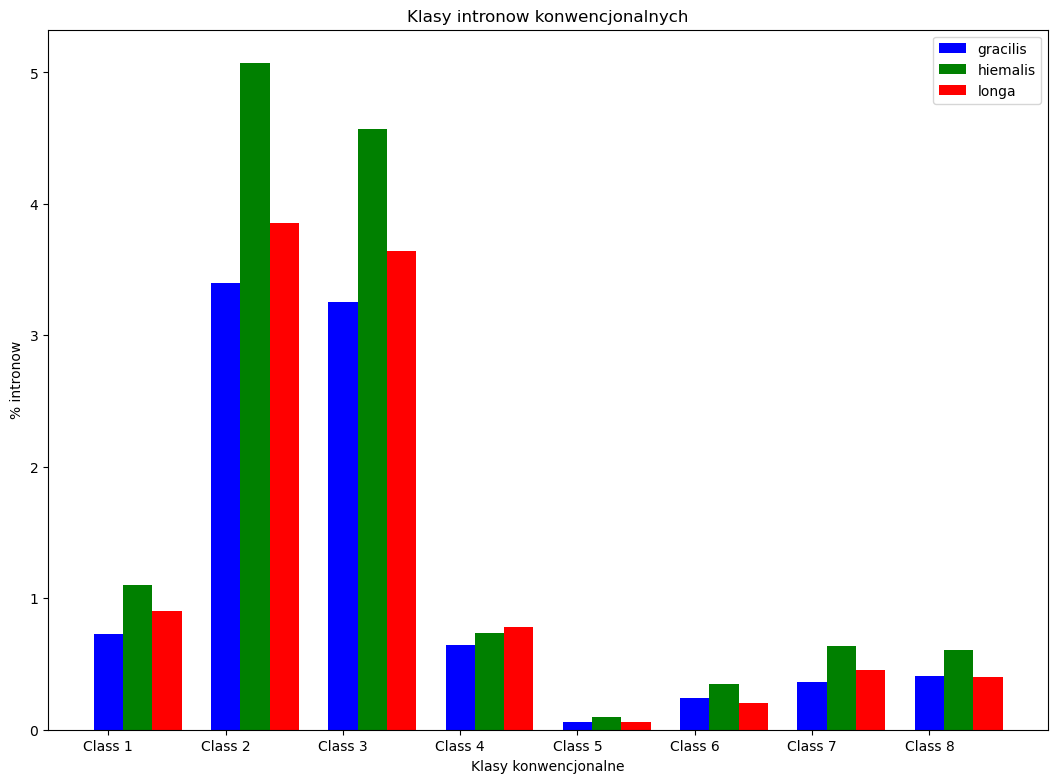

In [14]:
lista1=[i[1] for i in klasy]
data=[[j*100 for j in l] for l in lista1]
legenda=[i[0] for i in klasy]
X = np.arange(8)
fig = plt.figure(figsize=(10,7))
ax = fig.add_axes([0,0,1,1])
r1=ax.bar(X + 0.00, data[0], color = 'b', width = 0.25)
r2=ax.bar(X + 0.25, data[1], color = 'g', width = 0.25)
r3=ax.bar(X + 0.50, data[2], color = 'r', width = 0.25)
ax.set_title('Klasy intronów konwencjonalnych')
ax.set_xlabel('Klasy konwencjonalne')
ax.set_ylabel('% intronów')
ax.set_xticks(X)
ax.set_xticklabels(('Klasa 1', 'Klasa 2', 'Klasa 3', 'Klasa 4', 'Klasa 5', 'Klasa 6', 'Klasa 7', 'Klasa 8'))
ax.legend(legenda)

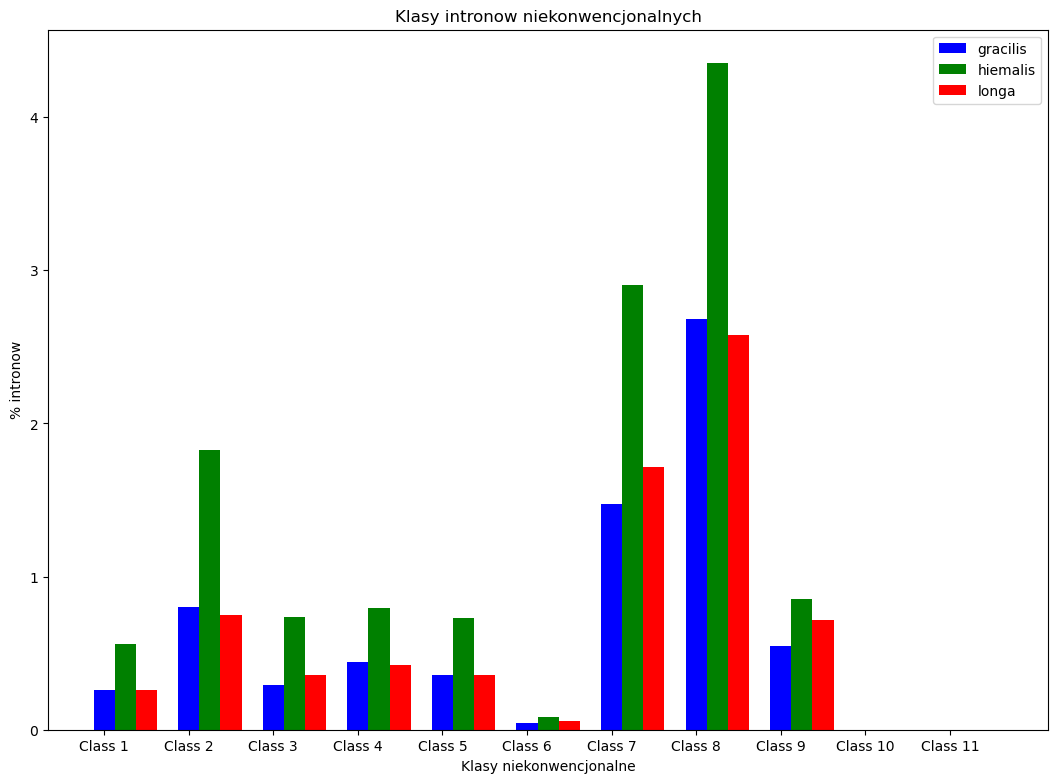

In [1]:
lista1=[i[2] for i in klasy]
data=[[j*100 for j in l] for l in lista1]
'''legenda=[i[0] for i in klasy]
Y = np.arange(9)
fig = plt.figure(figsize=(10,7))
ax = fig.add_axes([0,0,1,1])
ax.bar(Y + 0.00, data[0], color = 'b', width = 0.25)
ax.bar(Y + 0.25, data[1], color = 'g', width = 0.25)
ax.bar(Y + 0.50, data[2], color = 'r', width = 0.25)
ax.set_title('Klasy intronów niekonwencjonalnych')
ax.set_xlabel('Klasy niekonwencjonalne')
ax.set_ylabel('% intronów')
ax.set_xticks(Y)
ax.set_xticklabels(('Klasa 1', 'Klasa 2', 'Klasa 3', 'Klasa 4', 'Klasa 5', 'Klasa 6', 'Klasa 7', 'Klasa 8', 'Klasa 9'))
ax.legend(legenda)
plt.savefig("klasy_niekonwencjonalne.png")'''
with open('klasy_niekonwencjonalne.csv', 'w') as f:
    writer=csv.writer(f)
    writer.writerows(data)

[[17.39837174247578, 11.663238773362266, 0.553221612563713, 70.38516787159824], [24.471134586566567, 19.48990341102984, 0.7403670677606493, 55.29859493464294], [20.513759146024558, 12.048573920667417, 0.5500042933778037, 66.88766263993023]]


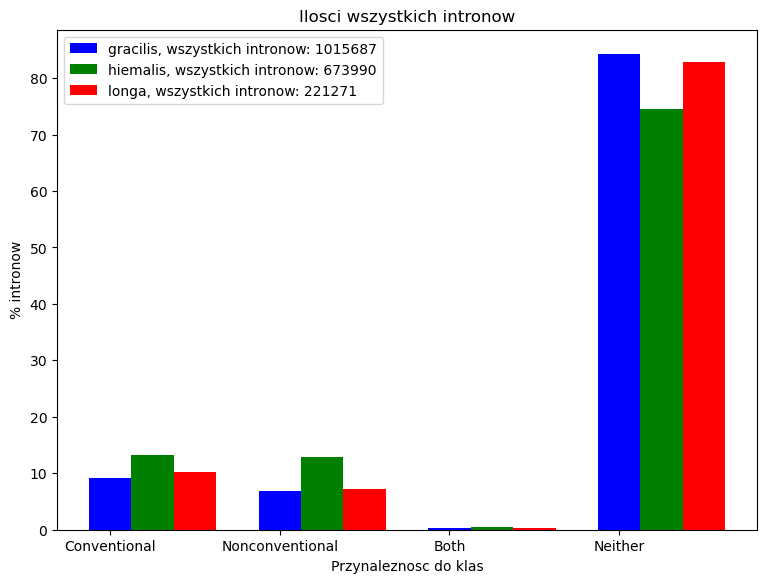

In [16]:
data=[[j*100 for j in l[1:-1]] for l in counts]
print(data)
labels=[i[0] for i in counts]
Z = np.arange(4)
fig = plt.figure(figsize=(7,5))
ax = fig.add_axes([0,0,1,1])
ax.bar(Z + 0.00, data[0], color = 'b', width = 0.25)
ax.bar(Z + 0.25, data[1], color = 'g', width = 0.25)
ax.bar(Z + 0.50, data[2], color = 'r', width = 0.25)
ax.set_title('Ilości wszystkich intronów')
ax.set_xlabel('Przynależność do klas')
ax.set_ylabel('% intronów')
ax.set_xticks(Z)
ax.set_xticklabels(('Konwencjonalne','Niekonwencjonalne', 'Oba','Żadne'))
ax.legend(labels)